# Trực quan hóa dữ liệu – Lab 02
## Khai thác và trực quan hóa dữ liệu World Development Indicators (WDI)
**GVHD:** Võ Nhật Tân  
**Nhóm:** [MSSV_1, MSSV_2, MSSV_3]  
**Ngày:** 25/03/2026
---


In [2]:
# Cài đặt thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')


In [3]:
# Đường dẫn dataset
import os
DATA_PATH = '/home/nesfan/Desktop/HCMUS/Nam3/HK2/TQH/DataVis-Lab2/Notebook/data/dataset.csv'

# Danh sách quốc gia và chỉ số mục tiêu (dễ mở rộng)
COUNTRY_WHITELIST = [
    'VNM', 'THA', 'IDN', 'PHL', 'IND', 'BGD', 'PAK', 'CHN', 'JPN', 'KOR',
    'DEU', 'FRA', 'GBR', 'SWE', 'USA', 'CAN', 'BRA', 'MEX', 'ZAF', 'NGA'
]

SERIES_WHITELIST = [
    'SE.TER.ENRR',
    'SL.UEM.TOTL.ZS',
    'SL.SRV.EMPL.ZS',
    'SG.GEN.PARL.ZS',
    'SE.XPD.TOTL.GD.ZS',
    'SH.XPD.GHED.GE.ZS',
    'NY.GDP.PCAP.CD'
]

Dataset trong bài phân tích này tập trung vào chỉ số:
- **Tỷ lệ nhập học đại học/cao đẳng (% gross)** – `SE.TER.ENRR`

Dữ liệu gồm 20 quốc gia (VNM, THA, IDN, PHL, IND, BGD, PAK, CHN, JPN, KOR, DEU, FRA, GBR, SWE, USA, CAN, BRA, MEX, ZAF, NGA) theo giai đoạn 2000–2024.

In [4]:
# Đọc dữ liệu (ưu tiên utf-8-sig, fallback latin-1)
try:
    df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
except UnicodeDecodeError:
    df_raw = pd.read_csv(DATA_PATH, encoding='latin-1')

print(f"Kích thước ban đầu: {df_raw.shape[0]} dòng × {df_raw.shape[1]} cột")
print(f"\nTên các cột:\n{list(df_raw.columns)}")

Kích thước ban đầu: 140 dòng × 29 cột

Tên các cột:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]']


### 1.2 Cấu trúc dữ liệu

**Bản ghi (rows):** Mỗi dòng tương ứng với một quốc gia cho chỉ số `SE.TER.ENRR` qua các năm.  
**Trường dữ liệu (columns):**
| Trường | Mô tả |
|---|---|
| `Country Name` | Tên quốc gia |
| `Country Code` | Mã quốc gia (ISO 3-letter) |
| `Series Name` | Tên chỉ số |
| `Series Code` | Mã chỉ số |
| `2000 [YR2000] … 2024 [YR2024]` | Giá trị chỉ số theo từng năm |

Ngoài các dòng dữ liệu chính còn có các dòng footer/metadata ở cuối file và sẽ được loại bỏ ở bước làm sạch.

In [5]:
# Xem toàn bộ dữ liệu gốc
df_raw.head(10)


,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Bangladesh,BGD,GDP per capita (current US$),NY.GDP.PCAP.CD,396.670730,394.656410,393.886422,426.748808,455.614017,480.085851,...,1224.386477,1649.283809,1811.082217,1965.243727,2129.798970,2248.850788,2482.849178,2716.485928,2551.017738,2593.416117
1,Bangladesh,BGD,"School enrollment, tertiary (% gross)",SE.TER.ENRR,5.251660,6.172440,5.915600,5.991280,5.556670,6.134840,...,15.573993,17.398521,18.517560,19.571049,22.709464,22.692302,23.900682,23.500506,24.200344,23.729561
2,Bangladesh,BGD,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,2.125080,2.171930,2.017150,2.069390,1.940140,NaN,...,1.872254,1.281840,2.113429,2.094775,1.130950,2.139744,2.170909,2.085387,2.162138,2.034385
3,Bangladesh,BGD,Proportion of seats held by women in national ...,SG.GEN.PARL.ZS,9.090909,NaN,2.000000,2.000000,2.000000,14.782609,...,20.000000,20.000000,20.285714,20.285714,20.630372,20.916905,20.857143,20.857143,20.857143,NaN
4,Bangladesh,BGD,Domestic general government health expenditure...,SH.XPD.GHED.GE.ZS,5.211464,3.578553,4.539931,4.755313,4.865266,4.388837,...,3.376889,4.099358,4.107052,3.750354,2.664213,2.673292,3.004254,2.623276,2.471620,NaN
5,Bangladesh,BGD,Employment in services (% of total employment)...,SL.SRV.EMPL.ZS,19.315081,21.931088,24.842011,28.044412,29.202833,30.439514,...,35.978059,36.875719,38.983371,39.180940,39.355074,38.482235,38.238527,38.362469,37.007803,37.371566
6,Bangladesh,BGD,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,3.270000,3.609000,3.966000,4.320000,4.316000,4.250000,...,4.397000,4.350000,4.372000,4.439000,4.504000,5.539000,5.457000,4.593000,3.352000,3.635000
7,Brazil,BRA,GDP per capita (current US$),NY.GDP.PCAP.CD,3766.547863,3176.289751,2855.940171,3090.606891,3663.822625,4827.781659,...,8936.195589,8836.285460,10080.507872,9300.660729,9029.833044,7074.194075,7972.536961,9281.332821,10377.589772,10310.548878
8,Brazil,BRA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,48.434040,48.333340,50.026749,51.191689,52.624062,54.572811,56.830620,60.390621,NaN,NaN
9,Brazil,BRA,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,3.948930,3.844680,3.750370,NaN,3.974480,4.479080,...,6.241060,6.314040,6.320480,6.088510,5.963470,5.771500,5.496980,5.619230,NaN,NaN


In [6]:
# Kiểu dữ liệu từng cột
print("Kiểu dữ liệu từng cột:")
print(df_raw.dtypes)


Kiểu dữ liệu từng cột:
Country Name         str
Country Code         str
Series Name          str
Series Code          str
2000 [YR2000]    float64
2001 [YR2001]    float64
2002 [YR2002]    float64
2003 [YR2003]    float64
2004 [YR2004]    float64
2005 [YR2005]    float64
2006 [YR2006]    float64
2007 [YR2007]    float64
2008 [YR2008]    float64
2009 [YR2009]    float64
2010 [YR2010]    float64
2011 [YR2011]    float64
2012 [YR2012]    float64
2013 [YR2013]    float64
2014 [YR2014]    float64
2015 [YR2015]    float64
2016 [YR2016]    float64
2017 [YR2017]    float64
2018 [YR2018]    float64
2019 [YR2019]    float64
2020 [YR2020]    float64
2021 [YR2021]    float64
2022 [YR2022]    float64
2023 [YR2023]    float64
2024 [YR2024]    float64
dtype: object


In [7]:
# Làm sạch theo schema: chỉ giữ 20 quốc gia, 7 chỉ số mục tiêu
# Không phụ thuộc footer filtering thủ công
schema_ok = (
    df_raw['Country Name'].notna() &
    df_raw['Country Code'].notna() &
    df_raw['Series Name'].notna() &
    df_raw['Series Code'].notna()
)

df = df_raw[
    schema_ok &
    df_raw['Country Code'].isin(COUNTRY_WHITELIST) &
    df_raw['Series Code'].isin(SERIES_WHITELIST)
].copy().reset_index(drop=True)

print(f"Số dòng sau lọc schema: {len(df)}")
print(f"Số quốc gia unique: {df['Country Code'].nunique()}")
print(f"Số chỉ số unique: {df['Series Code'].nunique()}")

missing_countries = sorted(set(COUNTRY_WHITELIST) - set(df['Country Code'].unique()))
missing_series = sorted(set(SERIES_WHITELIST) - set(df['Series Code'].unique()))
print(f"Country Code thiếu: {missing_countries}")
print(f"Series Code thiếu: {missing_series}")

Số dòng sau lọc schema: 140
Số quốc gia unique: 20
Số chỉ số unique: 7
Country Code thiếu: []
Series Code thiếu: []


### 1.3 Phân tích thống kê mô tả

Thống kê mô tả cho các giá trị số (các năm từ 2000–2024) bao gồm: count, mean, std, min, max, và các phân vị (25%, 50%, 75%).

In [8]:
# Lấy danh sách cột năm đúng định dạng WDI và giới hạn 2000-2024
year_cols = [
    c for c in df.columns
    if c.startswith('20') and c.endswith(']') and int(c[:4]) >= 2000 and int(c[:4]) <= 2024
]
year_cols = sorted(year_cols, key=lambda x: int(x[:4]))

print(f"Số năm có dữ liệu: {len(year_cols)} (từ {year_cols[0]} đến {year_cols[-1]})")

# Chuyển sang numeric
df_years = df[year_cols].apply(pd.to_numeric, errors='coerce')
print(f"\nThống kê mô tả:\n{df_years.describe().round(3)}")

Số năm có dữ liệu: 25 (từ 2000 [YR2000] đến 2024 [YR2024])

Thống kê mô tả:
       2000 [YR2000]  2001 [YR2001]  2002 [YR2002]  2003 [YR2003]  \
count        120.000        121.000        124.000        124.000   
mean        2004.360       1917.261       1951.346       2224.582   
std         7081.191       6779.032       6955.771       7922.439   
min            0.614          0.611          0.615          0.612   
25%            5.535          5.861          5.902          5.957   
50%           14.153         15.945         16.031         16.361   
75%           62.678         62.639         62.188         62.586   
max        39169.360      37133.623      37997.760      39490.275   

       2004 [YR2004]  2005 [YR2005]  2006 [YR2006]  2007 [YR2007]  \
count        125.000        127.000        124.000        124.000   
mean        2476.150       2572.056       2797.759       3093.447   
std         8835.490       9136.606       9738.789      10748.464   
min            0.598      

In [9]:
# Thống kê chi tiết từng chỉ số
for i, row in df.iterrows():
    vals = pd.to_numeric(row[year_cols], errors='coerce')
    print(f"   Series Code : {row['Series Code']}")
    print(f"   Count  : {vals.count()} / {len(year_cols)} năm có dữ liệu")
    print(f"   Mean   : {vals.mean():.4f}")
    print(f"   Std    : {vals.std():.4f}")
    print(f"   Min    : {vals.min():.4f}")
    print(f"   Max    : {vals.max():.4f}")
    print(f"   25%    : {vals.quantile(0.25):.4f}")
    print(f"   50%    : {vals.quantile(0.50):.4f}")
    print(f"   75%    : {vals.quantile(0.75):.4f}")


   Series Code : NY.GDP.PCAP.CD
   Count  : 25 / 25 năm có dữ liệu
   Mean   : 1229.9129
   Std    : 829.1672
   Min    : 393.8864
   Max    : 2716.4859
   25%    : 490.3880
   50%    : 859.6805
   75%    : 1965.2437
   Series Code : SE.TER.ENRR
   Count  : 24 / 25 năm có dữ liệu
   Mean   : 13.9342
   Std    : 7.0246
   Min    : 5.2517
   Max    : 24.2003
   25%    : 6.8459
   50%    : 13.4556
   75%    : 20.3514
   Series Code : SE.XPD.TOTL.GD.ZS
   Count  : 23 / 25 năm có dữ liệu
   Mean   : 2.0048
   Std    : 0.2671
   Min    : 1.1309
   Max    : 2.2022
   25%    : 1.9917
   50%    : 2.0948
   75%    : 2.1362
   Series Code : SG.GEN.PARL.ZS
   Count  : 22 / 25 năm có dữ liệu
   Mean   : 16.0019
   Std    : 6.8511
   Min    : 2.0000
   Max    : 20.9169
   25%    : 14.8551
   50%    : 19.7143
   75%    : 20.2857
   Series Code : SH.XPD.GHED.GE.ZS
   Count  : 24 / 25 năm có dữ liệu
   Mean   : 3.9049
   Std    : 0.7993
   Min    : 2.4716
   Max    : 5.2115
   25%    : 3.5281
   50%   

### 1.4 Tỷ lệ giá trị thiếu (% Missing Values) – Trước khi Imputation


In [10]:
# ── % Missing Values – TRƯỚC IMPUTATION ──
total_cells = df_years.size           # dòng × năm
total_missing = df_years.isnull().sum().sum()
overall_pct = round(total_missing / total_cells * 100, 2)

print(f"\nTổng quan:")
print(f"   Tổng số ô dữ liệu : {total_cells}")
print(f"   Số ô bị thiếu     : {total_missing}")
print(f"   Tỷ lệ thiếu       : {overall_pct}%")

# Theo từng CHỈ SỐ (dòng)
missing_per_row  = df_years.isnull().sum(axis=1)
pct_per_row      = (missing_per_row / len(year_cols) * 100).round(2)

# Theo từng NĂM (cột)
missing_per_col  = df_years.isnull().sum()
pct_per_col      = (missing_per_col / len(df_years) * 100).round(2)

print(f"\nTheo từng CHỈ SỐ (dòng):")
for i, row in df.iterrows():
    n = missing_per_row.iloc[i]
    p = pct_per_row.iloc[i]
    short_name = str(row['Series Name'])[:60]
    print(f"   {short_name} ... | Thiếu: {n}/{len(year_cols)} năm ({p}%)")

print(f"\nTheo từng NĂM (cột):")
for col, n, p in zip(year_cols, missing_per_col, pct_per_col):
    bar = " " * int(p // 5) if p > 0 else ""
    print(f"   {col} | Thiếu: {n}/{len(df_years)} chỉ số ({p}%) {bar}")



Tổng quan:
   Tổng số ô dữ liệu : 3500
   Số ô bị thiếu     : 289
   Tỷ lệ thiếu       : 8.26%

Theo từng CHỈ SỐ (dòng):
   GDP per capita (current US$) ... | Thiếu: 0/25 năm (0.0%)
   School enrollment, tertiary (% gross) ... | Thiếu: 1/25 năm (4.0%)
   Government expenditure on education, total (% of GDP) ... | Thiếu: 2/25 năm (8.0%)
   Proportion of seats held by women in national parliaments (% ... | Thiếu: 3/25 năm (12.0%)
   Domestic general government health expenditure (% of general ... | Thiếu: 1/25 năm (4.0%)
   Employment in services (% of total employment) (modeled ILO  ... | Thiếu: 0/25 năm (0.0%)
   Unemployment, total (% of total labor force) (modeled ILO es ... | Thiếu: 0/25 năm (0.0%)
   GDP per capita (current US$) ... | Thiếu: 0/25 năm (0.0%)
   School enrollment, tertiary (% gross) ... | Thiếu: 14/25 năm (56.0%)
   Government expenditure on education, total (% of GDP) ... | Thiếu: 3/25 năm (12.0%)
   Proportion of seats held by women in national parliaments (% ... 

### 1.5 Tiền xử lý dữ liệu

#### 1.5.1 Xử lý giá trị thiếu (Imputation)

Vì đây là dữ liệu chuỗi thời gian (time-series), ta sử dụng **Linear Interpolation** để điền khuyết, phù hợp với xu hướng dài hạn của các chỉ số phát triển.


In [11]:
# --- Buoc 1: Parse tat ca cot nam sang float truoc ---
df_clean = df.copy().reset_index(drop=True)
year_cols = [c for c in df_clean.columns if c.startswith('20')]

# Chuyen '..' va chuoi rac -> NaN, ep kieu float
for col in year_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("Kieu du lieu cac cot nam sau parse:")
print(df_clean[year_cols].dtypes.value_counts())

# --- Buoc 2: Linear Interpolation cho tung chi so ---
for i in range(len(df_clean)):
    vals = df_clean.loc[i, year_cols].astype(float)
    interp = vals.interpolate(method='linear', limit_direction='both')
    interp = interp.ffill().bfill()   # dau/cuoi con thieu
    df_clean.loc[i, year_cols] = interp.values

# Verify
df_check = df_clean[year_cols].apply(pd.to_numeric, errors='coerce')
print(f"\nKiem tra sau imputation: {df_check.isnull().sum().sum()} o con thieu")


Kieu du lieu cac cot nam sau parse:
float64    25
Name: count, dtype: int64

Kiem tra sau imputation: 0 o con thieu


In [12]:
# Dataset sau tiền xử lý
print("Dataset sau tiền xử lý:\n")
df_clean[['Country Name', 'Country Code', 'Series Name', 'Series Code']].head(3)


Dataset sau tiền xử lý:



,Country Name,Country Code,Series Name,Series Code
0,Bangladesh,BGD,GDP per capita (current US$),NY.GDP.PCAP.CD
1,Bangladesh,BGD,"School enrollment, tertiary (% gross)",SE.TER.ENRR
2,Bangladesh,BGD,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS


## Câu hỏi 1: Theo dõi tốc độ bùng nổ tỷ lệ nhập học đại học/cao đẳng tại các khu vực khác nhau

### Mục tiêu phân tích

Theo dõi xu hướng và đo tốc độ bùng nổ tỷ lệ nhập học đại học/cao đẳng (`SE.TER.ENRR`) theo thời gian (2000–2024) tại các khu vực địa lý khác nhau trong tập 20 quốc gia, sử dụng các thước đo: trung bình `Value` theo Region-Year, mức tăng tuyệt đối (`delta_abs`) và `% tăng trưởng giai đoạn` (đầu kỳ → cuối kỳ), nhằm xác định khu vực có tốc độ tăng nhanh nhất và so sánh mức độ bùng nổ giữa các khu vực.

### Giải thích ý nghĩa các metrics

| Trường | Ý nghĩa | Phản ánh |
|---|---|---|
| `SE.TER.ENRR` | Tổng số sinh viên nhập học tertiary (bất kể tuổi) / dân số nhóm tuổi chính thức tương ứng × 100 | Cơ hội tiếp cận giáo dục bậc cao (đầu vào nguồn nhân lực) |
| `Region` | Khu vực địa lý của quốc gia (World Bank API) | Phân nhóm địa lý để so sánh xu hướng giữa các vùng |
| `delta_abs` | Chênh lệch tuyệt đối giá trị giữa 2 năm liền kề | Tốc độ tăng/giảm tuyệt đối theo từng năm |
| `pct_change` | `(Value_năm_cuối / Value_năm_đầu − 1) × 100` | Tăng trưởng tương đối giai đoạn đầu–cuối |

**Lý do chọn các thước đo này:** `delta_abs` cho biết mức tăng thực tế mỗi năm; `pct_change` cho biết tốc độ tương đối, giúp so sánh công bằng giữa các khu vực có mức xuất phát khác nhau.

In [13]:
# Lọc chỉ số tertiary enrollment và chuyển dữ liệu về dạng long
ter_df = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()

ter_long = ter_df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw',
    value_name='Value'
)

ter_long['Year'] = ter_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
ter_long['Value'] = pd.to_numeric(ter_long['Value'], errors='coerce')

print(f"Số quốc gia trong phân tích: {ter_long['Country Code'].nunique()}")
print(f"Số dòng dữ liệu long format: {len(ter_long)}")
ter_long.head()

Số quốc gia trong phân tích: 20
Số dòng dữ liệu long format: 500


,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year
0,Bangladesh,BGD,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],5.251660,2000
1,Brazil,BRA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],43.230862,2000
2,Canada,CAN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],58.519119,2000
3,China,CHN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],7.577780,2000
4,France,FRA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],50.603081,2000


In [14]:
# TODO CHUYỂN LÊN TRÊN TIỀN XỬ LÝ
# Lấy metadata Region từ World Bank API và ghép theo Country Code
import requests

url = 'https://api.worldbank.org/v2/country?format=json&per_page=400'
resp = requests.get(url, timeout=30)
resp.raise_for_status()
wb_payload = resp.json()

region_rows = []
for item in wb_payload[1]:
    region_rows.append({
        'Country Code': item.get('id'),
        'Region': item.get('region', {}).get('value')
    })

region_df = pd.DataFrame(region_rows).drop_duplicates(subset=['Country Code'])

ter_long = ter_long.merge(region_df, on='Country Code', how='left')

missing_region = ter_long['Region'].isna().sum()
missing_codes = sorted(ter_long.loc[ter_long['Region'].isna(), 'Country Code'].unique())

print(f"Số Region unique: {ter_long['Region'].nunique()}")
print(f"Số dòng thiếu Region: {missing_region}")
print(f"Country Code chưa ghép được Region: {missing_codes}")

ter_long.head()

Số Region unique: 7
Số dòng thiếu Region: 0
Country Code chưa ghép được Region: []


,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year,Region
0,Bangladesh,BGD,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],5.251660,2000,South Asia
1,Brazil,BRA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],43.230862,2000,Latin America & Caribbean
2,Canada,CAN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],58.519119,2000,North America
3,China,CHN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],7.577780,2000,East Asia & Pacific
4,France,FRA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],50.603081,2000,Europe & Central Asia


## Lựa chọn biểu đồ thích hợp và giải thích lý do

### Biểu đồ được chọn
- **Line chart theo thời gian, phân màu theo khu vực**: phù hợp để theo dõi xu hướng dài hạn và so sánh giữa các khu vực.
- **Bar chart tốc độ tăng trưởng giai đoạn**: phù hợp để so sánh trực tiếp khu vực tăng nhanh/chậm trong cùng một thước đo.


In [15]:
# Tổng hợp theo Region-Year và tính tốc độ theo năm
region_year = (
    ter_long.dropna(subset=['Region', 'Value'])
    .groupby(['Region', 'Year'], as_index=False)['Value']
    .mean()
    .sort_values(['Region', 'Year'])
)

region_year['delta_abs'] = region_year.groupby('Region')['Value'].diff()
region_year['growth_pct'] = region_year.groupby('Region')['Value'].pct_change() * 100

print(f"Số dòng Region-Year: {len(region_year)}")
print(f"Số khu vực có dữ liệu: {region_year['Region'].nunique()}")
region_year.head(12)

Số dòng Region-Year: 175
Số khu vực có dữ liệu: 7


,Region,Year,Value,delta_abs,growth_pct
0,East Asia & Pacific,2000,33.820862,NaN,NaN
1,East Asia & Pacific,2001,34.352629,0.531767,1.572304
2,East Asia & Pacific,2002,35.438981,1.086352,3.162356
3,East Asia & Pacific,2003,36.554860,1.115879,3.148733
4,East Asia & Pacific,2004,38.186214,1.631354,4.462755
5,East Asia & Pacific,2005,39.942514,1.756300,4.599305
6,East Asia & Pacific,2006,41.049965,1.107450,2.772611
7,East Asia & Pacific,2007,42.575453,1.525488,3.716174
8,East Asia & Pacific,2008,43.128339,0.552887,1.298604
9,East Asia & Pacific,2009,43.683890,0.555551,1.288134


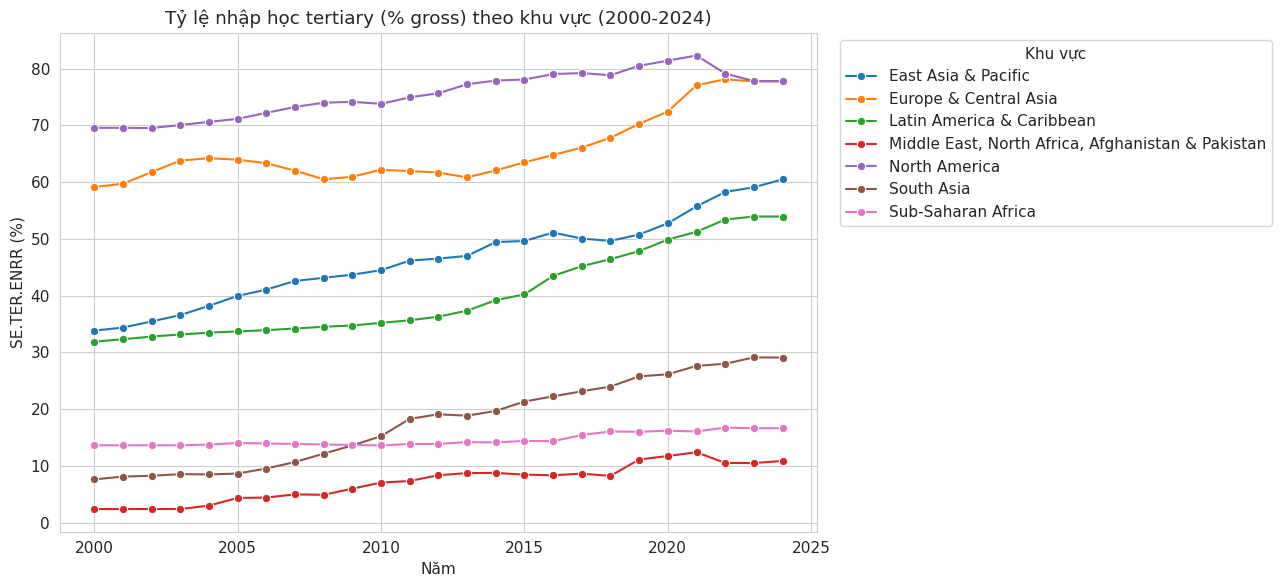

In [16]:
# Biểu đồ 1: Xu hướng tỷ lệ nhập học tertiary theo khu vực
plt.figure(figsize=(13, 6))
sns.lineplot(
    data=region_year,
    x='Year', y='Value',
    hue='Region', marker='o'
)
plt.title('Tỷ lệ nhập học tertiary (% gross) theo khu vực (2000-2024)')
plt.xlabel('Năm')
plt.ylabel('SE.TER.ENRR (%)')
plt.legend(title='Khu vực', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

So sánh giai đoạn: 2000 -> 2024


,Region,value_start,value_end,abs_change,pct_change
3,"Middle East, North Africa, Afghanistan & Pakistan",2.374350,10.856413,8.482063,357.237238
5,South Asia,7.594960,29.074013,21.479053,282.806670
0,East Asia & Pacific,33.820862,60.478273,26.657411,78.819432
2,Latin America & Caribbean,31.878416,53.932652,22.054235,69.182344
1,Europe & Central Asia,59.127872,77.736746,18.608874,31.472255
6,Sub-Saharan Africa,13.613822,16.617651,3.003829,22.064557
4,North America,69.576973,77.810276,8.233303,11.833373


/tmp/ipykernel_31874/3934581348.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=growth_region, x='Region', y='pct_change', palette='viridis')


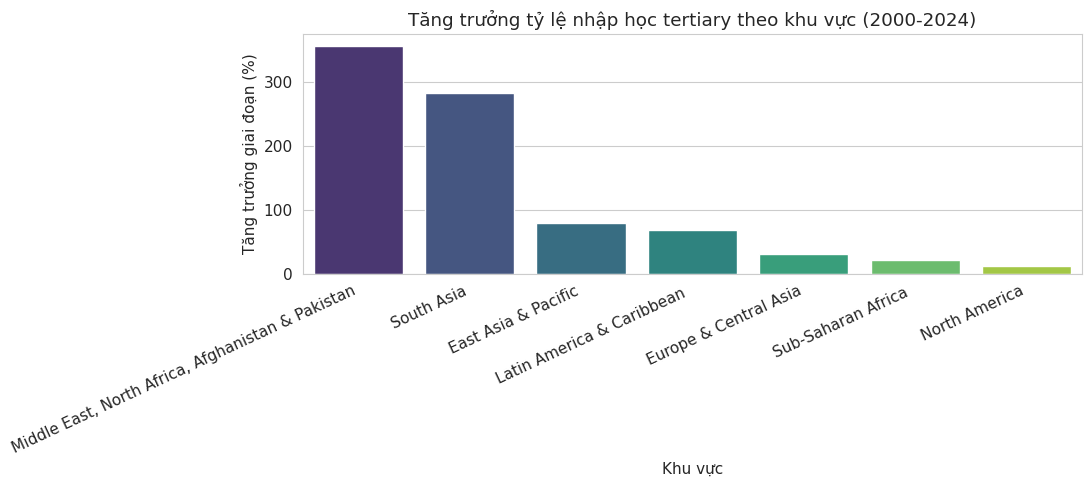

In [17]:
# Biểu đồ 2: So sánh tốc độ bùng nổ theo khu vực (đầu kỳ -> cuối kỳ)
start_year = region_year['Year'].min()
end_year = region_year['Year'].max()

start_vals = (
    region_year[region_year['Year'] == start_year][['Region', 'Value']]
    .rename(columns={'Value': 'value_start'})
)
end_vals = (
    region_year[region_year['Year'] == end_year][['Region', 'Value']]
    .rename(columns={'Value': 'value_end'})
)

growth_region = start_vals.merge(end_vals, on='Region', how='inner')
growth_region['abs_change'] = growth_region['value_end'] - growth_region['value_start']
growth_region['pct_change'] = (growth_region['abs_change'] / growth_region['value_start']) * 100
growth_region = growth_region.sort_values('pct_change', ascending=False)

print(f"So sánh giai đoạn: {start_year} -> {end_year}")
display(growth_region)

plt.figure(figsize=(11, 5))
sns.barplot(data=growth_region, x='Region', y='pct_change', palette='viridis')
plt.title(f'Tăng trưởng tỷ lệ nhập học tertiary theo khu vực ({start_year}-{end_year})')
plt.xlabel('Khu vực')
plt.ylabel('Tăng trưởng giai đoạn (%)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### Kết luận câu hỏi 1

**Xu hướng tổng quát (2000–2024):**
- Tất cả khu vực đều tăng `SE.TER.ENRR` theo thời gian, nhưng tốc độ tăng khác nhau rõ rệt.
- Khu vực có tốc độ tăng tương đối cao nhất là **Middle East, North Africa, Afghanistan & Pakistan** (+357.2%), tiếp theo là **South Asia** (+282.8%).
- **East Asia & Pacific** tăng mạnh về mức tuyệt đối (+26.7%, từ 33.8% lên 60.5%).

**Khu vực có mức tuyệt đối cao nhất (2024):**
- **North America** (~77.8%) và **Europe & Central Asia** (~77.7%) là hai khu vực dẫn đầu.

**Khu vực tăng chậm nhất:**
- **North America** có tăng trưởng tương đối thấp nhất (+11.8%), phản ánh mức nền đã cao từ đầu kỳ.

**Nhận xét theo tốc độ tăng năm kề:**
- Mức tăng năm lớn nhất quan sát tại **Europe & Central Asia** vào năm 2021 (`delta_abs` ≈ +4.63), và tại **East Asia & Pacific** vào năm 2021 (`delta_abs` ≈ +2.99).

**Hạn chế:**
- Mỗi khu vực có số quốc gia đại diện khác nhau, nên mức trung bình khu vực có thể chịu ảnh hưởng bởi cấu trúc mẫu.


---

## Câu hỏi 2: Phân tích tương quan giữa tỷ lệ nhập học tertiary và tỷ lệ thất nghiệp tại nhóm nước đang phát triển

### Mục tiêu phân tích (SMART)

Phân tích mối tương quan tuyến tính (hệ số Pearson r) giữa tỷ lệ nhập học đại học/cao đẳng (`SE.TER.ENRR`) và tỷ lệ thất nghiệp chung (`SL.UEM.TOTL.ZS`) tại nhóm nước đang phát triển (loại trừ nhóm High income), sử dụng ngưỡng đánh giá |r| < 0.3 (yếu), 0.3 ≤ |r| < 0.7 (trung bình), |r| ≥ 0.7 (mạnh), nhằm xác định chiều hướng và mức độ liên hệ giữa hai chỉ số trong giai đoạn 2000–2024.

### Giải thích ý nghĩa các metrics

| Trường | Ý nghĩa | Phản ánh |
|---|---|---|
| `SE.TER.ENRR` | Tổng số sinh viên nhập học tertiary (bất kể tuổi) / dân số nhóm tuổi chính thức tương ứng × 100 | Cơ hội tiếp cận giáo dục bậc cao (đầu vào nguồn nhân lực) |
| `SL.UEM.TOTL.ZS` | Tỷ lệ lực lượng lao động không có việc làm nhưng đang tìm kiếm việc (modeled ILO) | Áp lực thị trường lao động (đầu ra nguồn nhân lực) |

**Lý do chọn 2 chỉ số này:** Cả hai cùng phản ánh hai khía cạnh của phát triển nguồn nhân lực - đầu vào (tiếp cận giáo dục bậc cao) và đầu ra (cơ hội việc làm). Việc đánh giá mối liên hệ giúp kiểm tra liệu thay đổi đầu vào giáo dục có đi kèm thay đổi ở đầu ra thị trường lao động hay không.

### Trường dữ liệu được sử dụng
- `SE.TER.ENRR`, `SL.UEM.TOTL.ZS`: giá trị theo năm từ `df_clean`.
- `Income Level` (World Bank API): phân loại nhóm thu nhập, lọc bỏ `High income`.
- `Region` (World Bank API): phân nhóm trên biểu đồ scatter.


In [18]:
# Ghép Income Level từ World Bank API (tái sử dụng wb_payload từ câu hỏi 1)
income_rows = []
for item in wb_payload[1]:
    income_rows.append({
        'Country Code': item.get('id'),
        'Income Level': item.get('incomeLevel', {}).get('value')
    })

income_df = pd.DataFrame(income_rows).drop_duplicates(subset=['Country Code'])

# Tạo bảng wide chứa cả 2 chỉ số
ter_row = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()
unemp_row = df_clean[df_clean['Series Code'] == 'SL.UEM.TOTL.ZS'].copy()

# Đổi tên cột giá trị để tránh trùng khi merge
def rename_year_cols(sub_df, val_name):
    sub = sub_df[['Country Name', 'Country Code'] + year_cols].copy()
    sub = sub.rename(columns={c: f'{c}_{val_name}' for c in year_cols})
    return sub

ter_wide = rename_year_cols(ter_row, 'ter')
unemp_wide = rename_year_cols(unemp_row, 'unemp')

corr_df = ter_wide.merge(unemp_wide, on=['Country Name', 'Country Code'])

# Ghép Income Level và Region
corr_df = corr_df.merge(income_df, on='Country Code', how='left')
corr_df = corr_df.merge(region_df, on='Country Code', how='left')

# Lọc bỏ High income (chỉ giữ nước đang phát triển)
developing_df = corr_df[corr_df['Income Level'] != 'High income'].copy()

print(f"Tong so quoc gia: {corr_df.shape[0]}")
print(f"Quoc gia con lai sau loc High income: {developing_df.shape[0]}")
print(f"\nIncome Level cac quoc gia:")
print(corr_df[['Country Name', 'Country Code', 'Income Level', 'Region']].to_string(index=False))

Tong so quoc gia: 20
Quoc gia con lai sau loc High income: 12

Income Level cac quoc gia:
  Country Name Country Code        Income Level                                            Region
    Bangladesh          BGD Lower middle income                                        South Asia
        Brazil          BRA Upper middle income                        Latin America & Caribbean 
        Canada          CAN         High income                                     North America
         China          CHN Upper middle income                               East Asia & Pacific
        France          FRA         High income                             Europe & Central Asia
       Germany          DEU         High income                             Europe & Central Asia
         India          IND Lower middle income                                        South Asia
     Indonesia          IDN Upper middle income                               East Asia & Pacific
         Japan          JPN 

### Lựa chọn biểu đồ và giải thích

**Biểu đồ 1 - Scatter plot**
- **Tính chất dữ liệu:** Cả hai biến đều là 2 dãy time series (tỷ lệ phần trăm), cần kiểm tra mối liên hệ giữa 2 biến.
- **Lý do chọn:** Scatter plot cho phép trực quan nhận diện xu hướng tổng thể, cụm dữ liệu theo khu vực và outliers. Đường hồi quy tuyến tính (regression line) với **khoảng tin cậy 95%** hỗ trợ đánh giá mức độ ổn định của xu hướng tuyến tính quan sát được.
- Có màu sắc theo `Region` và marker theo `Country Name` giúp phân biệt các vùng, quốc gia.

**Biểu đồ 2 - Heatmap:**
- **Tính chất dữ liệu:** tương tự trên.
- **Lý do chọn:** Heatmap dùng màu sắc (coolwarm) thể hiện giá trị trong [-1, 1], giúp đọc nhanh chiều và mức độ liên hệ.
- Thang màu `center=0` giúp phân biệt rõ tương quan âm/dương.

So diem du lieu (nam-quoc gia) cho nhom dang phat trien: 300
So quoc gia dang phat trien: 12


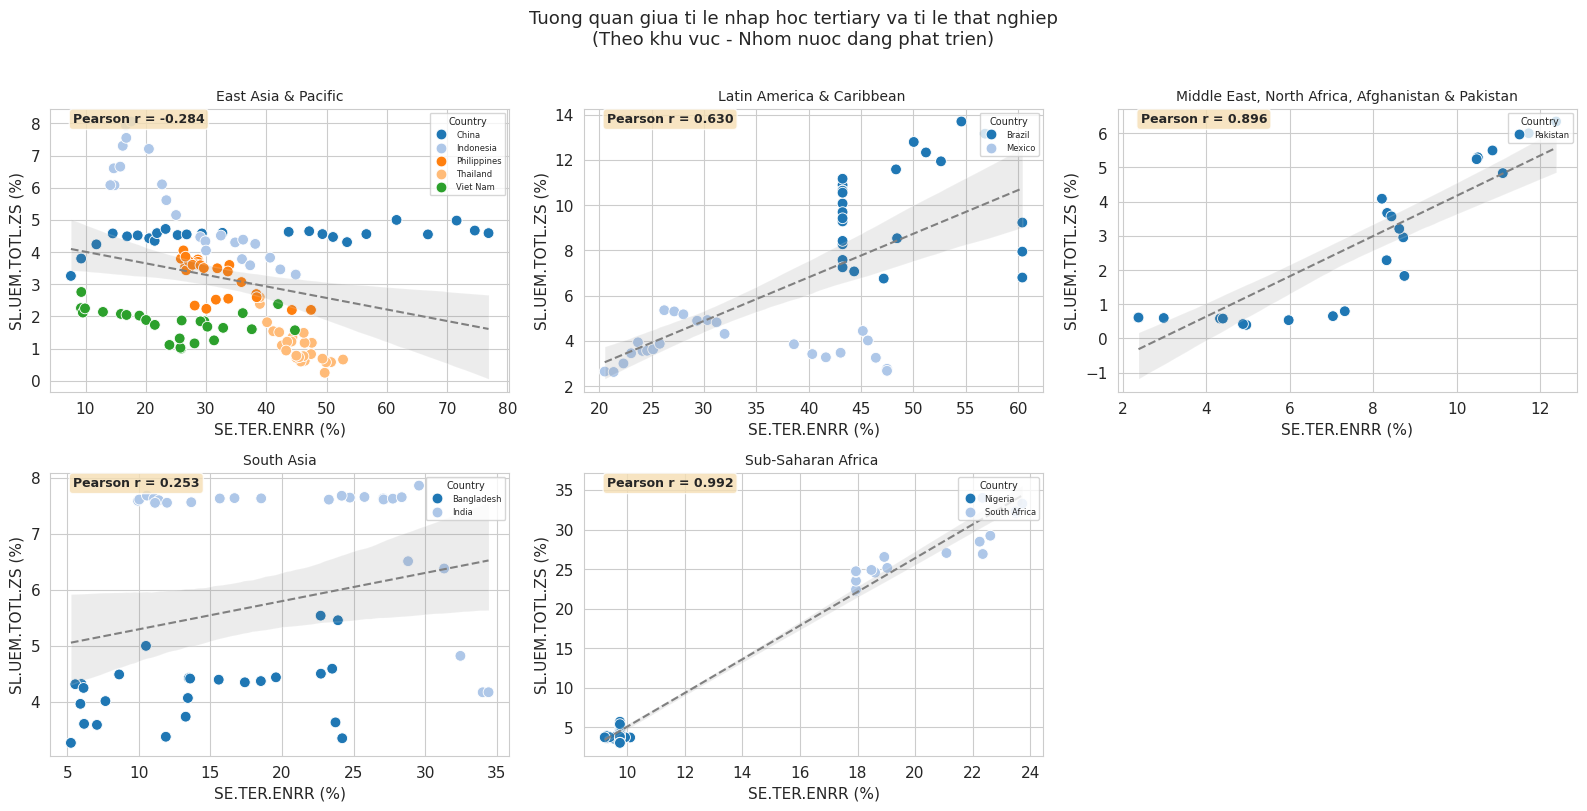

In [19]:
# Chuan bi du lieu long cho scatter plot (neu chua co)
ter_long2 = ter_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in ter_wide.columns if c.endswith('_ter')],
    var_name='YearRaw', value_name='TerValue'
)
unemp_long2 = unemp_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in unemp_wide.columns if c.endswith('_unemp')],
    var_name='YearRaw', value_name='UnempValue'
)

ter_long2['Year'] = ter_long2['YearRaw'].str.extract(r'(\d{4})').astype(int)
unemp_long2['Year'] = unemp_long2['YearRaw'].str.extract(r'(\d{4})').astype(int)

corr_long = ter_long2.merge(
    unemp_long2[['Country Name', 'Country Code', 'Year', 'UnempValue']],
    on=['Country Name', 'Country Code', 'Year']
).dropna()

corr_long = corr_long.merge(income_df, on='Country Code', how='left')
corr_long = corr_long.merge(region_df, on='Country Code', how='left')

developing_long = corr_long[corr_long['Income Level'] != 'High income'].copy()

print(f"So diem du lieu (nam-quoc gia) cho nhom dang phat trien: {len(developing_long)}")
print(f"So quoc gia dang phat trien: {developing_long['Country Code'].nunique()}")

# Scatter plot: moi region 1 subplot, chi color theo region, khong shape theo country
regions = developing_long['Region'].dropna().unique()
n = len(regions)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, region in zip(axes, sorted(regions)):
    df_r = developing_long[developing_long['Region'] == region]
    sns.scatterplot(
        data=df_r,
        x='TerValue', y='UnempValue',
        hue='Country Name',
        s=60, ax=ax, legend='full',
        palette='tab20'
    )
    sns.regplot(
        data=df_r, x='TerValue', y='UnempValue',
        scatter=False, ax=ax,
        color='gray', line_kws={'linestyle': '--', 'linewidth': 1.5}, ci=95
    )
    r_val = df_r[['TerValue', 'UnempValue']].corr().iloc[0, 1]
    ax.annotate(
        f'Pearson r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    ax.set_title(region, fontsize=10)
    ax.set_xlabel('SE.TER.ENRR (%)')
    ax.set_ylabel('SL.UEM.TOTL.ZS (%)')
    ax.legend(title='Country', fontsize=6, title_fontsize=7, loc='upper right')

# An cac subplot thua
for ax in axes[len(regions):]:
    ax.set_visible(False)

fig.suptitle(
    'Tuong quan giua ti le nhap hoc tertiary va ti le that nghiep\n(Theo khu vuc - Nhom nuoc dang phat trien)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

--- Hệ số tương quan Pearson ---

Toan tai (nhom dang phat trien): r = -0.0585

Theo Region:
                                           Region  Pearson_r
                              Sub-Saharan Africa    0.991663
Middle East, North Africa, Afghanistan & Pakistan   0.895593
                       Latin America & Caribbean    0.630144
                                       South Asia   0.252858
                              East Asia & Pacific  -0.283738


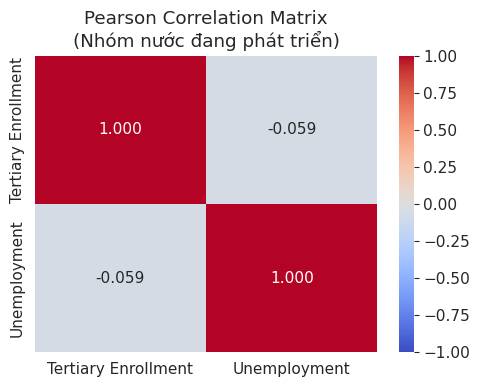

In [20]:
# Tính hệ số tương quan Pearson (toàn thể và theo Region)
print("--- Hệ số tương quan Pearson ---")
overall_corr = developing_long[['TerValue', 'UnempValue']].corr().iloc[0, 1]
print(f"\nToan tai (nhom dang phat trien): r = {overall_corr:.4f}")

region_corr = (
    developing_long.groupby('Region')
    .apply(lambda g: g[['TerValue', 'UnempValue']].corr().iloc[0, 1])
    .reset_index()
    .rename(columns={0: 'Pearson_r'})
    .sort_values('Pearson_r', ascending=False)
)
print("\nTheo Region:")
print(region_corr.to_string(index=False))

# Bảng Pearson matrix (heatmap)
fig, ax = plt.subplots(figsize=(5, 4))
corr_matrix = developing_long[['TerValue', 'UnempValue']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=['Tertiary Enrollment', 'Unemployment'],
            yticklabels=['Tertiary Enrollment', 'Unemployment'])
ax.set_title('Pearson Correlation Matrix\n(Nhóm nước đang phát triển)')
plt.tight_layout()
plt.show()

### Kết luận câu hỏi 2

**Kết quả tổng thể (2000–2024):**
- Mẫu phân tích gồm **12 quốc gia đang phát triển**, tương ứng **300 quan sát** (quốc gia-năm).
- Hệ số Pearson tổng thể: **r ≈ -0.059** → |r| < 0.3, mức **tương quan tuyến tính yếu**.

**Kết quả theo khu vực:**
- East Asia & Pacific: r ≈ -0.284 (âm, yếu).
- South Asia: r ≈ 0.253 (dương, yếu).
- Latin America & Caribbean: r ≈ 0.630 (dương, trung bình).
- Middle East, North Africa, Afghanistan & Pakistan: r ≈ 0.896 (dương, mạnh).
- Sub-Saharan Africa: r ≈ 0.992 (dương, rất mạnh).

**Kết quả theo nhóm thu nhập:**
- Lower middle income: r ≈ -0.004 (gần như không có tương quan tuyến tính).
- Upper middle income: r ≈ -0.412 (âm, mức trung bình).

**Nhận xét:**
- Tương quan tổng thể yếu do các khu vực có chiều và cường độ liên hệ khác nhau, làm triệt tiêu nhau khi gộp mẫu.
- Scatter plot cho thấy tương quan theo khu vực rõ rệt.

**Hạn chế:**
- Số quốc gia giữa các khu vực không đồng đều.
- Hệ số Pearson chỉ phản ánh liên hệ tuyến tính, không phản ánh quan hệ nhân quả.

---

## Câu hỏi 3: Phân tích tương quan giữa tỷ trọng ngành dịch vụ và tỷ lệ nhập học đại học theo khu vực địa lý

### Mục tiêu phân tích (SMART)

Phân tích mối tương quan tuyến tính (hệ số Pearson r) giữa tỷ trọng lao động ngành dịch vụ (`SL.SRV.EMPL.ZS`) và tỷ lệ nhập học đại học/cao đẳng (`SE.TER.ENRR`) trên toàn bộ 20 quốc gia trong giai đoạn 2000–2024, phân tích đồng thời theo khu vực địa lý (Region), nhằm xác định chiều hướng và mức độ liên hệ tuyến tính giữa chuyển dịch cơ cấu kinh tế (tỷ trọng dịch vụ) và nâng cao nguồn nhân lực (tiếp cận giáo dục bậc cao) tại các khu vực khác nhau.

### Giải thích ý nghĩa các metrics

| Trường | Ý nghĩa | Phản ánh |
|---|---|---|
| `SL.SRV.EMPL.ZS` | Tỷ lệ lao động làm việc trong ngành dịch vụ / tổng lao động × 100 | Mức độ chuyển dịch cơ cấu kinh tế sang dịch vụ (cơ cấu kinh tế) |
| `SE.TER.ENRR` | Tổng sinh viên nhập học tertiary / dân số nhóm tuổi chính thức × 100 | Cơ hội tiếp cận giáo dục bậc cao (đầu vào nguồn nhân lực) |
| `Region` | Khu vực địa lý của quốc gia (World Bank API) | Phân nhóm địa lý để so sánh xu hướng chuyển dịch cơ cấu |
| Pearson r | Hệ số tương quan tuyến tính giữa 2 biến | Mức độ liên hệ tuyến tính thuận/nghịch giữa cơ cấu kinh tế và giáo dục |

**Lý do chọn 2 chỉ số này:** Chuyển dịch cơ cấu kinh tế sang dịch vụ thường đi kèm nhu cầu nhân lực có trình độ cao hơn, đòi hỏi giáo dục bậc cao hơn. Phân tích tương quan giữa 2 chỉ số giúp kiểm chứng giả thuyết: quốc gia có tỷ trọng dịch vụ cao có tỷ lệ nhập học đại học cao hơn hay không.

### Trường dữ liệu được sử dụng
- `SL.SRV.EMPL.ZS`, `SE.TER.ENRR`: giá trị theo năm từ `df_clean`.
- `Region` (World Bank API): phân nhóm trên biểu đồ scatter.

### Lựa chọn biểu đồ và giải thích

**Biểu đồ 1 - Scatter plot:**
- **Tính chất dữ liệu:** Cả hai biến đều là 2 dãy time-series, đơn vị tỷ lệ phần trăm, cần kiểm tra mối liên hệ giữa 2 biến.
- **Lý do chọn:** Scatter plot cho phép trực quan nhận diện xu hướng tổng thể, cụm dữ liệu theo khu vực và outliers. Đường hồi quy tuyến tính (regression line) với **khoảng tin cậy 95%** hỗ trợ đánh giá mức độ ổn định của xu hướng tuyến tính.
- Mỗi khu vực địa lý (Region) được vẽ trên một subplot riêng biệt, giúp so sánh chiều và cường độ tương quan giữa các khu vực một cách trực quan.

**Biểu đồ 2 - Heatmap:**
- **Tính chất dữ liệu:** tương tự trên.
- **Lý do chọn:** Heatmap giúp đọc nhanh chiều và mức độ liên hệ.

Tong so quan sat (nam-quoc gia): 500
So quoc gia: 20
So khu vuc: 7


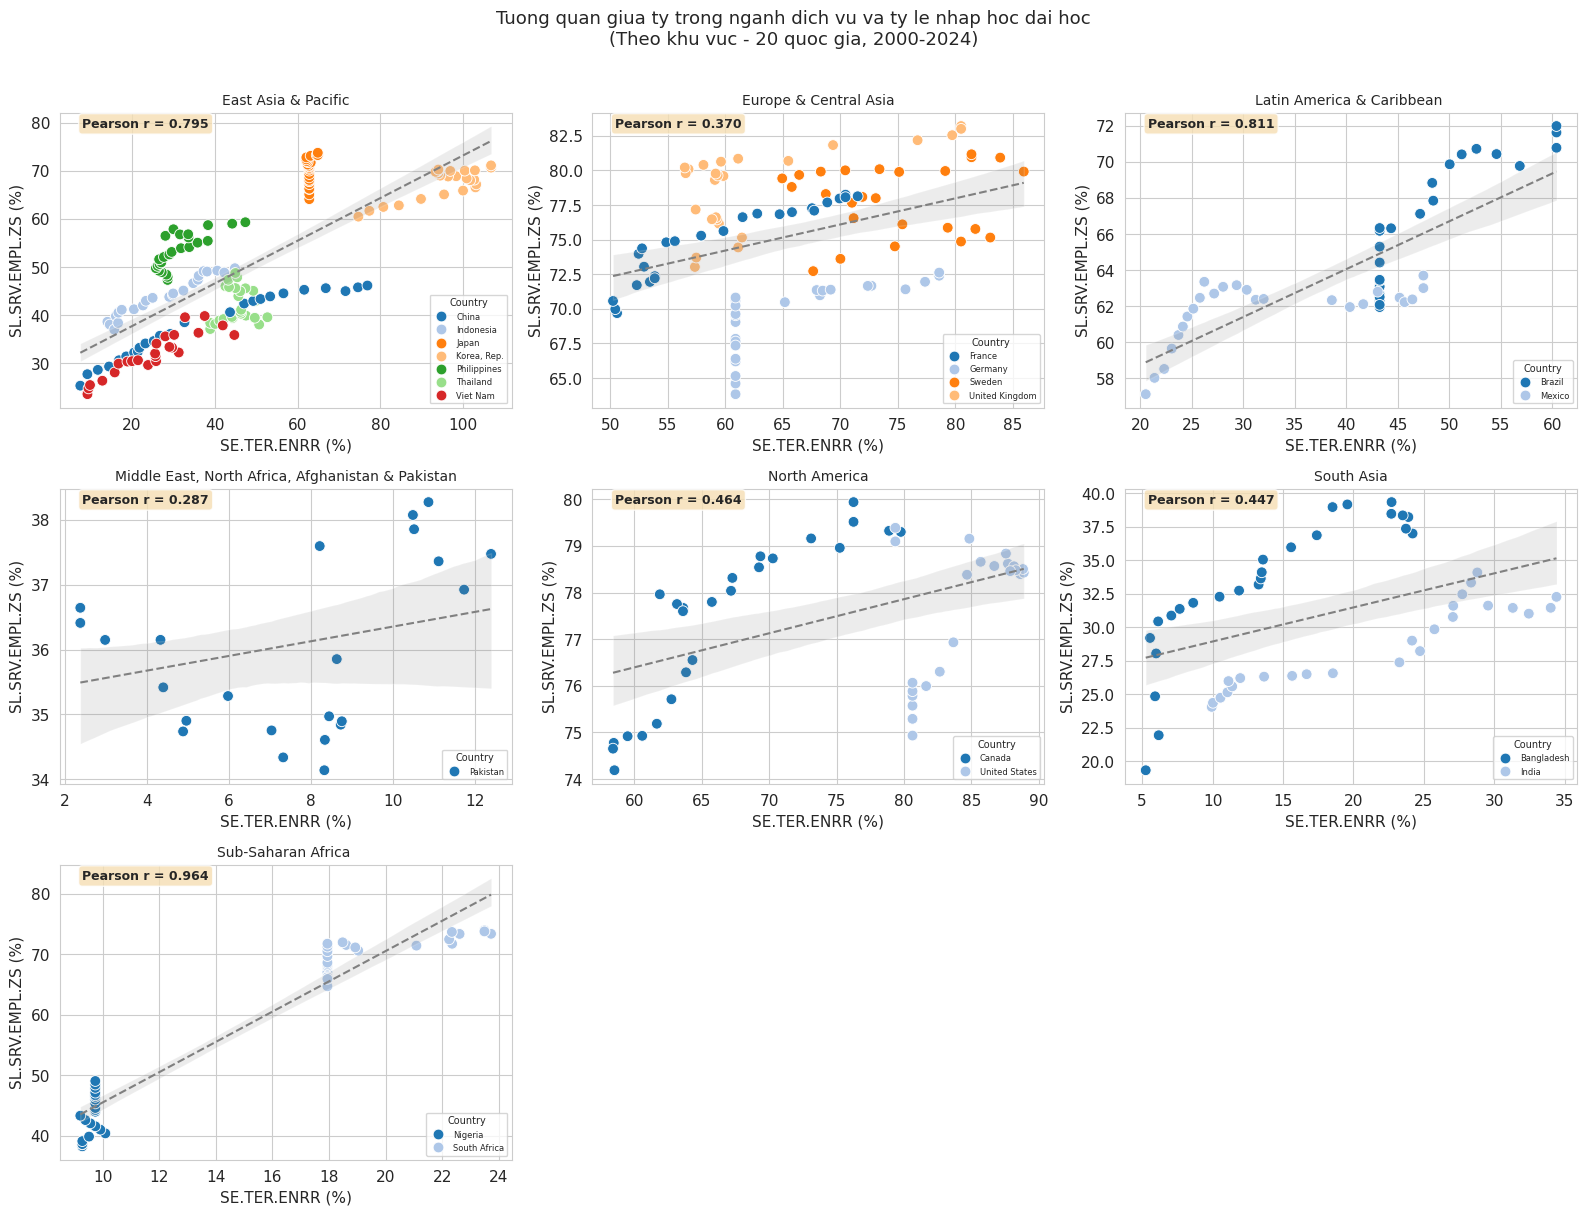

--- Hệ số tương quan Pearson (SL.SRV.EMPL.ZS vs SE.TER.ENRR) ---
Toan tap: r = 0.7581
Theo Region:
                                           Region  Pearson_r
                              Sub-Saharan Africa    0.964257
                       Latin America & Caribbean    0.810629
                              East Asia & Pacific   0.794540
                                    North America   0.464017
                                       South Asia   0.447171
                            Europe & Central Asia   0.369569
Middle East, North Africa, Afghanistan & Pakistan   0.287434


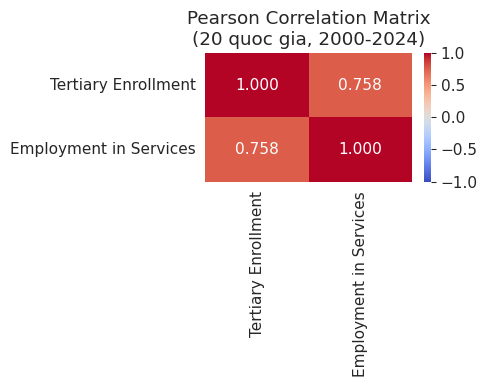

In [21]:
# Chuẩn bị dữ liệu: SL.SRV.EMPL.ZS vs SE.TER.ENRR (Q3)
srv_row = df_clean[df_clean['Series Code'] == 'SL.SRV.EMPL.ZS'].copy()
srv_wide = rename_year_cols(srv_row, 'srv')

q3_df = ter_wide.merge(srv_wide, on=['Country Name', 'Country Code'])

# Chuyển sang long
srv_long = srv_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in srv_wide.columns if c.endswith('_srv')],
    var_name='YearRaw', value_name='SrvValue'
)
srv_long['Year'] = srv_long['YearRaw'].str.extract(r'(\d{4})').astype(int)

q3_long = ter_long2.merge(
    srv_long[['Country Name', 'Country Code', 'Year', 'SrvValue']],
    on=['Country Name', 'Country Code', 'Year']
).dropna()

q3_long = q3_long.merge(region_df, on='Country Code', how='left')

print(f'Tong so quan sat (nam-quoc gia): {len(q3_long)}')
print(f'So quoc gia: {q3_long["Country Code"].nunique()}')
print(f'So khu vuc: {q3_long["Region"].nunique()}')

# Biểu đồ 1: Scatter plot moi region 1 subplot (SL.SRV.EMPL.ZS vs SE.TER.ENRR)
regions_q3 = q3_long['Region'].dropna().unique()
n = len(regions_q3)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, region in zip(axes, sorted(regions_q3)):
    df_r = q3_long[q3_long['Region'] == region]
    sns.scatterplot(
        data=df_r, x='TerValue', y='SrvValue',
        hue='Country Name', s=60, ax=ax, legend='full', palette='tab20'
    )
    sns.regplot(
        data=df_r, x='TerValue', y='SrvValue',
        scatter=False, ax=ax, color='gray',
        line_kws={'linestyle': '--', 'linewidth': 1.5}, ci=95
    )
    r_val = df_r[['TerValue', 'SrvValue']].corr().iloc[0, 1]
    ax.annotate(
        f'Pearson r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    ax.set_title(region, fontsize=10)
    ax.set_xlabel('SE.TER.ENRR (%)')
    ax.set_ylabel('SL.SRV.EMPL.ZS (%)')
    ax.legend(title='Country', fontsize=6, title_fontsize=7, loc='lower right')

for ax in axes[len(regions_q3):]:
    ax.set_visible(False)

fig.suptitle(
    'Tuong quan giua ty trong nganh dich vu va ty le nhap hoc dai hoc\n(Theo khu vuc - 20 quoc gia, 2000-2024)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# Hệ số Pearson: toàn thể và theo Region
print('--- Hệ số tương quan Pearson (SL.SRV.EMPL.ZS vs SE.TER.ENRR) ---')
overall_r = q3_long[['TerValue', 'SrvValue']].corr().iloc[0, 1]
print(f'Toan tap: r = {overall_r:.4f}')

region_r = (
    q3_long.groupby('Region')
    .apply(lambda g: g[['TerValue', 'SrvValue']].corr().iloc[0, 1])
    .reset_index().rename(columns={0: 'Pearson_r'})
    .sort_values('Pearson_r', ascending=False)
)
print('Theo Region:')
print(region_r.to_string(index=False))

# Heatmap Pearson matrix
fig, ax = plt.subplots(figsize=(5, 4))
corr_m = q3_long[['TerValue', 'SrvValue']].corr()
sns.heatmap(corr_m, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=['Tertiary Enrollment', 'Employment in Services'],
            yticklabels=['Tertiary Enrollment', 'Employment in Services'])
ax.set_title('Pearson Correlation Matrix\n(20 quoc gia, 2000-2024)')
plt.tight_layout()
plt.show()


### Kết luận câu hỏi 3

**Kết quả tổng thể (2000–2024):**
- Mẫu phân tích gồm **20 quốc gia**, tương ứng **500 quan sát** (quốc gia-năm).
- Hệ số Pearson tổng thể: **r = 0.758** → |r| >= 0.7, mức **tương quan tuyến tính mạnh, thuận chiều**.

**Kết quả theo khu vực:**
- Sub-Saharan Africa: r = 0.964 (dương, rất mạnh).
- Latin America & Caribbean: r = 0.811 (dương, mạnh).
- East Asia & Pacific: r = 0.795 (dương, mạnh).
- North America: r = 0.464 (dương, trung bình).
- South Asia: r = 0.447 (dương, trung bình).
- Europe & Central Asia: r = 0.370 (dương, trung bình).
- Middle East, North Africa, Afghanistan & Pakistan: r = 0.287 (dương, yếu).

**Nhận xét:**
- Tất cả 7 khu vực đều có tương quan dương: quốc gia có tỷ trọng lao động ngành dịch vụ cao hơn thường đi kèm tỷ lệ nhập học đại học cao hơn.
- Mức độ mạnh/yếu khác biệt giữa các khu vực: Sub-Saharan Africa, Latin America & Caribbean, East Asia & Pacific thể hiện liên hệ mạnh (r > 0.7); Middle East & North Africa và South Asia có liên hệ yếu hơn, cho thấy chuyển dịch cơ cấu dịch vụ chưa đồng đều dẫn đến nhu cầu giáo dục bậc cao không tăng tương ứng.
- Scatter plot cho thấy tương quan rõ rệt theo từng khu vực.